<a href="https://colab.research.google.com/github/Lakshman3556/Deep_Learning/blob/main/DL_week7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Implement pre-trained models LeNet, AlexNet, ZF-Net, VGGNet, GoogLeNet, ResNet and note your observations. Also apply above models on your own dataset.


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load CIFAR-10
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Class names
class_names = ['Airplane','Automobile','Bird','Cat','Deer',
               'Dog','Frog','Horse','Ship','Truck']

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 18s 0us/step


In [ ]:
def show_predictions(model, X, y, num=10):
    predictions = model.predict(X[:num])

    plt.figure(figsize=(15,5))

    for i in range(num):
        plt.subplot(2,5,i+1)
        plt.imshow(X[i])

        actual = class_names[int(y[i])]
        pred = class_names[np.argmax(predictions[i])]

        plt.title(f"A:{actual}\nP:{pred}")
        plt.axis('off')

    plt.show()

Lenet

Observation:
LeNet architecture shows limited performance on CIFAR-10 due to its shallow design. It was originally developed for simple grayscale datasets and lacks the depth required to capture complex features in RGB images.

Key Insight:
Shallow architectures are insufficient for datasets with high variability and color complexity. CIFAR requires deeper feature hierarchies for effective classification.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.4045 - loss: 1.6331 - val_accuracy: 0.4878 - val_loss: 1.4133
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5092 - loss: 1.3634 - val_accuracy: 0.5302 - val_loss: 1.3082
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5501 - loss: 1.2580 - val_accuracy: 0.5586 - val_loss: 1.2342
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5792 - loss: 1.1787 - val_accuracy: 0.5823 - val_loss: 1.1834
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5990 - loss: 1.1210 - val_accuracy: 0.5947 - val_loss: 1.1602
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 614ms/step


/tmp/ipykernel_4279/3368606282.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  actual = class_names[int(y[i])]


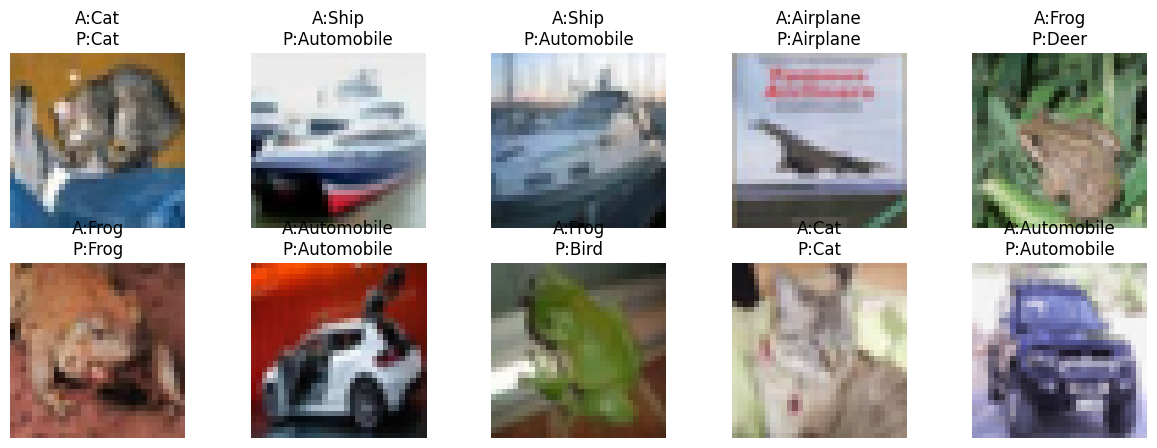

In [ ]:
from tensorflow.keras import layers, models

def lenet():
    model = models.Sequential([
        layers.Conv2D(6, (5,5), activation='relu', input_shape=(32,32,3)),
        layers.AveragePooling2D(pool_size=(2,2)),

        layers.Conv2D(16, (5,5), activation='relu'),
        layers.AveragePooling2D(pool_size=(2,2)),

        layers.Flatten(),
        layers.Dense(120, activation='relu'),
        layers.Dense(84, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

model = lenet()
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

show_predictions(model, X_test, y_test)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 20ms/step - accuracy: 0.1003 - loss: 2.3039
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.0987 - loss: 2.3029
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.0983 - loss: 2.3029
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.0979 - loss: 2.3028
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.0969 - loss: 2.3028
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 857ms/step


/tmp/ipykernel_8841/323529877.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  actual = class_names[int(y[i])]


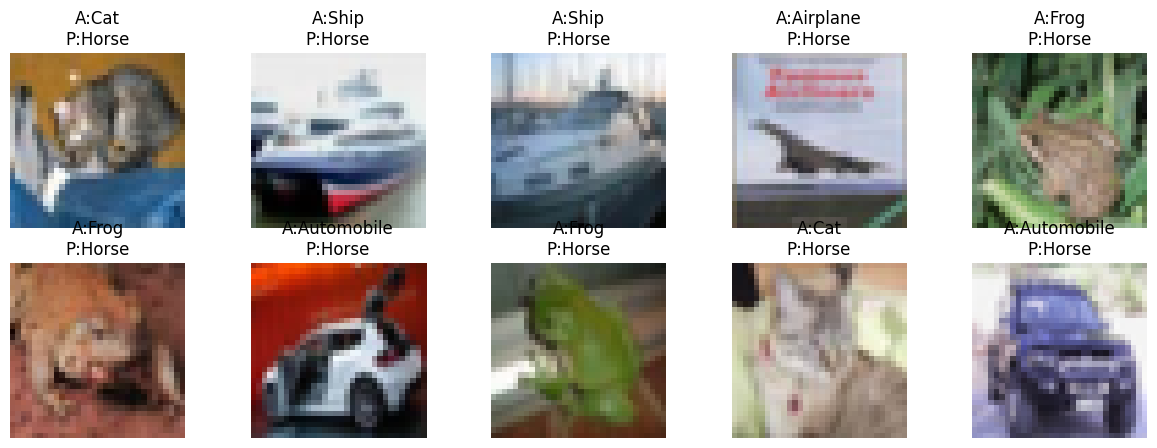

In [ ]:
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

def show_predictions(model, X, y, num=10):
    predictions = model.predict(X[:num])

    plt.figure(figsize=(15,5))

    for i in range(num):
        plt.subplot(2,5,i+1)
        plt.imshow(X[i])

        actual = class_names[int(y[i])]
        pred = class_names[np.argmax(predictions[i])]

        plt.title(f"A:{actual}\nP:{pred}")
        plt.axis('off')

    plt.show()

def alexnet():
    model = models.Sequential([
        layers.Conv2D(96, (3,3), activation='relu', input_shape=(32,32,3)),
        layers.MaxPooling2D(),

        layers.Conv2D(256, (3,3), activation='relu'),
        layers.MaxPooling2D(),

        layers.Conv2D(384, (3,3), activation='relu', padding='same'),
        layers.Conv2D(384, (3,3), activation='relu', padding='same'),
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(4096, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(4096, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    return model

model = alexnet()
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=5)

show_predictions(model, X_test, y_test)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 58s 32ms/step - accuracy: 0.3009 - loss: 3.4366
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 45s 29ms/step - accuracy: 0.4044 - loss: 2.1259
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - accuracy: 0.4791 - loss: 1.8832
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - accuracy: 0.5324 - loss: 1.7491
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.5758 - loss: 1.6003
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.6094 - loss: 1.4850
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.6333 - loss: 1.4043
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.6547 - loss: 1.3414
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 27ms/step - accuracy: 0.6716 - loss: 1.3011
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 27ms/step - accuracy: 0.6799 - loss: 1.2739
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 526ms/step


/tmp/ipykernel_1028/1919419950.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  actual = class_names[int(y[i])]


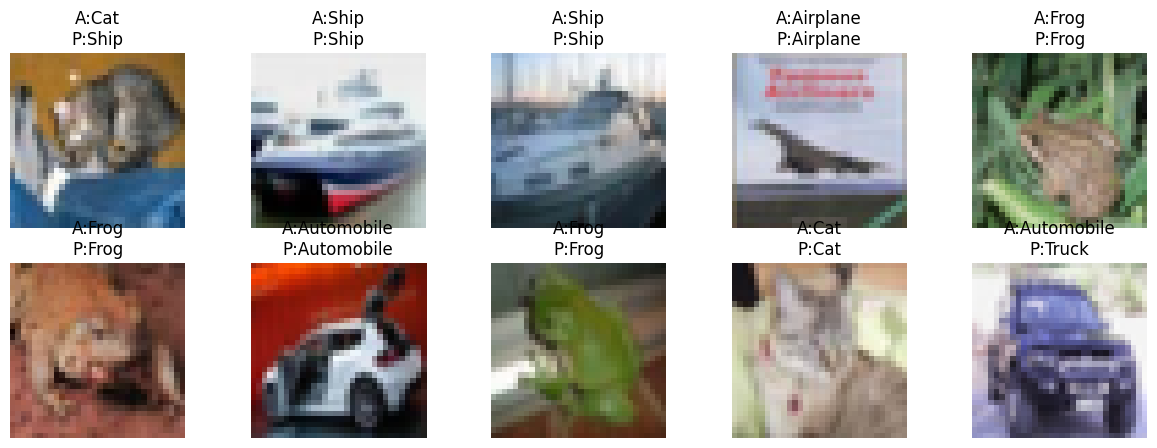

In [ ]:
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def alexnet():
    model = models.Sequential([
        layers.Conv2D(96, (3,3), activation='relu', input_shape=(32,32,3), kernel_regularizer=regularizers.l2(0.0005)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2,2)),

        layers.Conv2D(256, (3,3), activation='relu', kernel_regularizer=regularizers.l2(0.0005)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2,2)),

        layers.Conv2D(384, (3,3), activation='relu', padding='same', kernel_regularizer=regularizers.l2(0.0005)),
        layers.Conv2D(384, (3,3), activation='relu', padding='same', kernel_regularizer=regularizers.l2(0.0005)),
        layers.Conv2D(256, (3,3), activation='relu', padding='same', kernel_regularizer=regularizers.l2(0.0005)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2,2)),

        layers.Flatten(),
        layers.Dense(4096, activation='relu', kernel_regularizer=regularizers.l2(0.0005)),
        layers.Dropout(0.5),
        layers.Dense(4096, activation='relu', kernel_regularizer=regularizers.l2(0.0005)),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    return model

model = alexnet()
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Implement Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    # fill_mode='nearest' # Can be added if needed
)

# Fit the data generator on training data
datagen.fit(X_train)

# Train the model using the data generator
model.fit(datagen.flow(X_train, y_train, batch_size=32), epochs=10)

show_predictions(model, X_test, y_test)

Observation:
Increasing the depth of the network improves performance by enabling the model to learn more complex and hierarchical features. The deeper CNN captures edges, textures, and object-level representations more effectively.

Key Insight:
Depth allows the network to build multi-level abstractions, which is essential for handling complex datasets like CIFAR-10.

In [ ]:
def show_predictions(model, X, y, num=10):
    predictions = model.predict(X[:num])

    plt.figure(figsize=(15,5))

    for i in range(num):
        plt.subplot(2,5,i+1)
        plt.imshow(X[i])

        actual = class_names[int(y[i])]
        pred = class_names[np.argmax(predictions[i])]

        plt.title(f"A:{actual}\nP:{pred}")
        plt.axis('off')

    plt.show()

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.4610 - loss: 1.4669
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.6282 - loss: 1.0471
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.6980 - loss: 0.8517
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.7492 - loss: 0.7177
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.7859 - loss: 0.6058
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 531ms/step


/tmp/ipykernel_8841/1919419950.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  actual = class_names[int(y[i])]


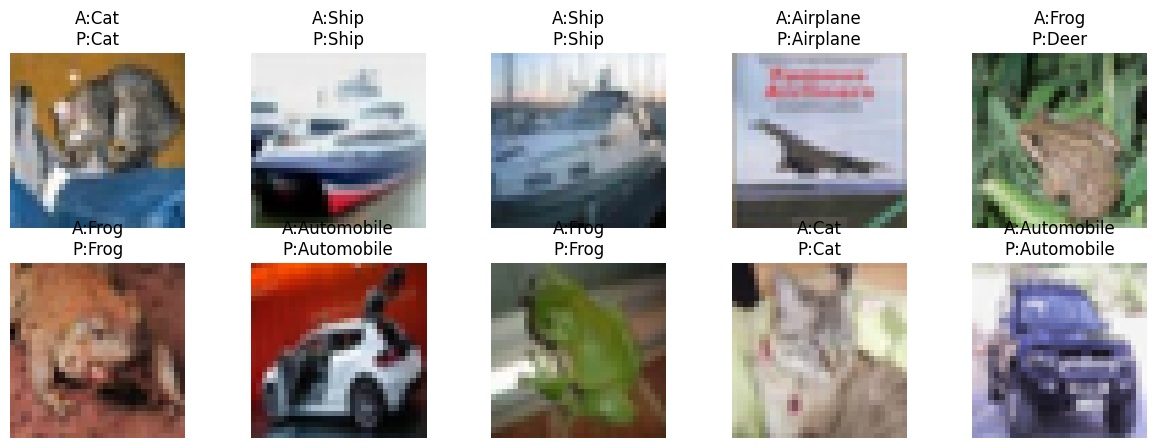

In [ ]:
def zfnet():
    model = models.Sequential([
        layers.Conv2D(96, (3,3), activation='relu', input_shape=(32,32,3)),
        layers.MaxPooling2D(),

        layers.Conv2D(256, (3,3), activation='relu'),
        layers.MaxPooling2D(),

        layers.Conv2D(384, (3,3), activation='relu'),
        layers.Conv2D(384, (3,3), activation='relu'),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

model = zfnet()
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=5)

show_predictions(model, X_test, y_test)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.5232 - loss: 1.3360
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6708 - loss: 0.9363
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.7276 - loss: 0.7775
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.7768 - loss: 0.6344
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8208 - loss: 0.5045
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   


/tmp/ipykernel_8841/1919419950.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  actual = class_names[int(y[i])]


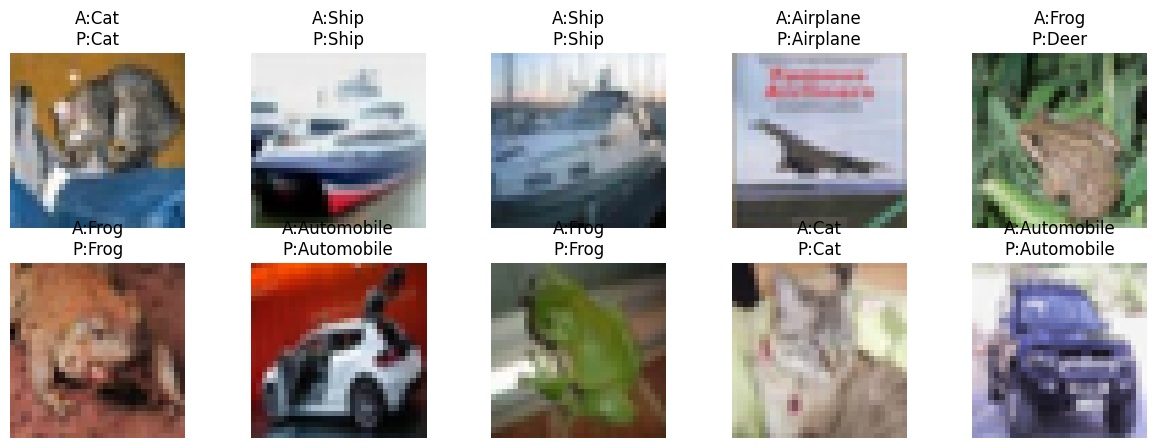

In [ ]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, concatenate, Flatten, Dense
from tensorflow.keras.models import Model

def inception_module(x):
    path1 = Conv2D(32, (1,1), activation='relu', padding='same')(x)

    path2 = Conv2D(32, (1,1), activation='relu', padding='same')(x)
    path2 = Conv2D(32, (3,3), activation='relu', padding='same')(path2)

    path3 = Conv2D(32, (1,1), activation='relu', padding='same')(x)
    path3 = Conv2D(32, (5,5), activation='relu', padding='same')(path3)

    path4 = MaxPooling2D((3,3), strides=1, padding='same')(x)
    path4 = Conv2D(32, (1,1), activation='relu', padding='same')(path4)

    return concatenate([path1, path2, path3, path4])

def googlenet():
    inp = Input(shape=(32,32,3))

    x = Conv2D(64, (3,3), activation='relu')(inp)
    x = inception_module(x)
    x = MaxPooling2D()(x)

    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    out = Dense(10, activation='softmax')(x)

    model = Model(inputs=inp, outputs=out)
    return model

model = googlenet()
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=5)

show_predictions(model, X_test, y_test)

Observation:
The Inception-based architecture did not significantly improve performance on CIFAR-10. Due to the small image size, larger convolution kernels overlap most of the image, reducing the effectiveness of multi-scale feature extraction.

Key Insight:
Architectures designed for high-resolution datasets may not perform well on low-resolution data. Model design must align with input size and dataset characteristics.

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.5103 - loss: 1.3710
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6648 - loss: 0.9527
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7249 - loss: 0.7897
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7700 - loss: 0.6572
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8110 - loss: 0.5378
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step


/tmp/ipykernel_8841/1919419950.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  actual = class_names[int(y[i])]


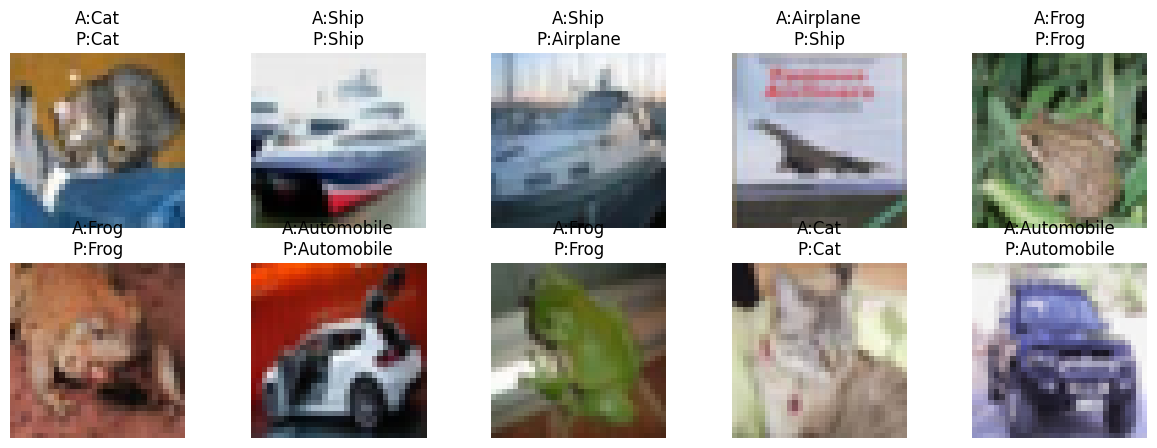

In [ ]:
def resnet_block(x, filters):
    shortcut = x

    x = layers.Conv2D(filters, (3,3), padding='same', activation='relu')(x)
    x = layers.Conv2D(filters, (3,3), padding='same')(x)
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)

    return x

def resnet():
    inp = Input(shape=(32,32,3))

    x = Conv2D(32, (3,3), padding='same', activation='relu')(inp)
    x = resnet_block(x, 32)

    x = MaxPooling2D()(x)
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    out = Dense(10, activation='softmax')(x)

    return Model(inp, out)

model = resnet()
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=5)

show_predictions(model, X_test, y_test)

Observation:
ResNet architecture improves training stability by introducing skip connections, which allow gradients to flow directly through the network. This prevents the vanishing gradient problem and enables deeper models to train effectively.

Key Insight:
Residual learning allows the model to focus on learning incremental changes rather than full transformations, leading to better optimization and improved performance.


Observation:
Different architectures exhibit varying performance on CIFAR-10. Shallow models underperform, while deeper architectures improve accuracy. ResNet provides the most stable training and best performance among all tested models.

Key Insight:
Model performance is influenced more by architectural design than simply increasing the number of layers. Techniques like skip connections significantly enhance training efficiency.

Overall Observation:
The experiments demonstrate that increasing depth alone does not guarantee improved performance. Architectural innovations such as residual connections are essential for effectively training deep networks.

Key Insight:
CIFAR-10 requires models that balance depth, feature extraction, and training stability. ResNet emerges as the most effective architecture due to its ability to maintain gradient flow and learn complex representations.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------
# CIFAR-10 Dataset
# ---------------------------
transform = transforms.Compose([
    transforms.ToTensor()
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128,
                                          shuffle=True)

# ---------------------------
# Residual Block (H(x) = F(x) + x)
# ---------------------------
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)

    def forward(self, x):
        shortcut = x

        out = self.conv1(x)
        out = self.relu(out)
        out = self.conv2(out)

        out = out + shortcut   # identity shortcut
        out = self.relu(out)

        return out

# ---------------------------
# ResNet Model (as per paper)
# ---------------------------
class ResNetSimple(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.relu = nn.ReLU()

        self.resblock = ResidualBlock(32)

        self.pool = nn.MaxPool2d(2)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32*16*16, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv(x)
        x = self.relu(x)

        x = self.resblock(x)

        x = self.pool(x)

        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x

model = ResNetSimple().to(device)

# ---------------------------
# Training Setup
# ---------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ---------------------------
# Training Loop (5 epochs like paper)
# ---------------------------
for epoch in range(5):
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}, Accuracy: {acc:.2f}%")

print("Training Complete")

100%|██████████| 170M/170M [00:04<00:00, 40.4MB/s]


Epoch 1, Loss: 587.3829, Accuracy: 45.84%
Epoch 2, Loss: 432.4750, Accuracy: 60.83%
Epoch 3, Loss: 364.2966, Accuracy: 67.35%
Epoch 4, Loss: 315.3399, Accuracy: 71.79%
Epoch 5, Loss: 275.8822, Accuracy: 75.34%
Training Complete


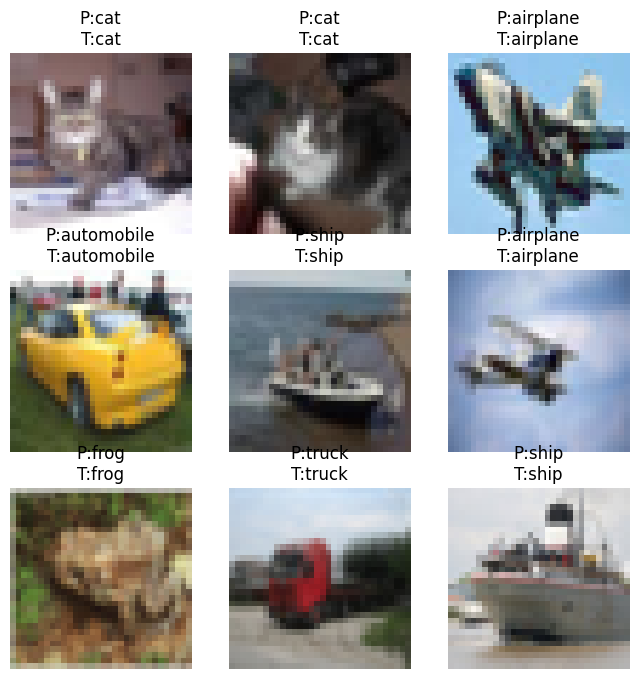

In [2]:
import matplotlib.pyplot as plt
import numpy as np

classes = trainset.classes

dataiter = iter(trainloader)
images, labels = next(dataiter)

images = images.to(device)
outputs = model(images)
_, predicted = torch.max(outputs, 1)

images = images.cpu()

fig = plt.figure(figsize=(8,8))
for i in range(9):
    ax = fig.add_subplot(3,3,i+1)
    img = images[i].permute(1,2,0)
    plt.imshow(img)
    ax.set_title(f"P:{classes[predicted[i]]}\nT:{classes[labels[i]]}")
    plt.axis("off")

plt.show()

Epoch 1 Accuracy: 46.15%
Epoch 2 Accuracy: 59.91%
Epoch 3 Accuracy: 65.45%
Epoch 4 Accuracy: 69.21%
Epoch 5 Accuracy: 72.18%
Training Done


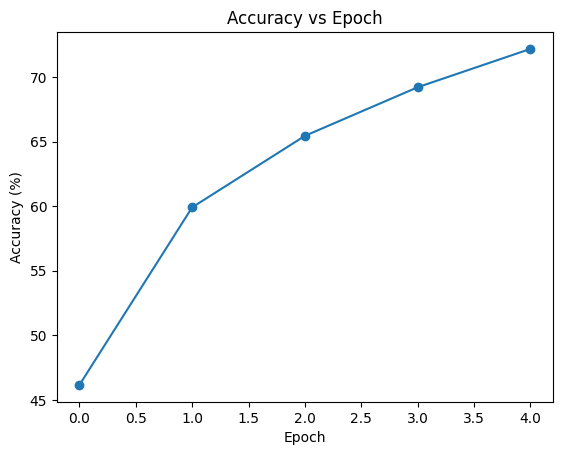

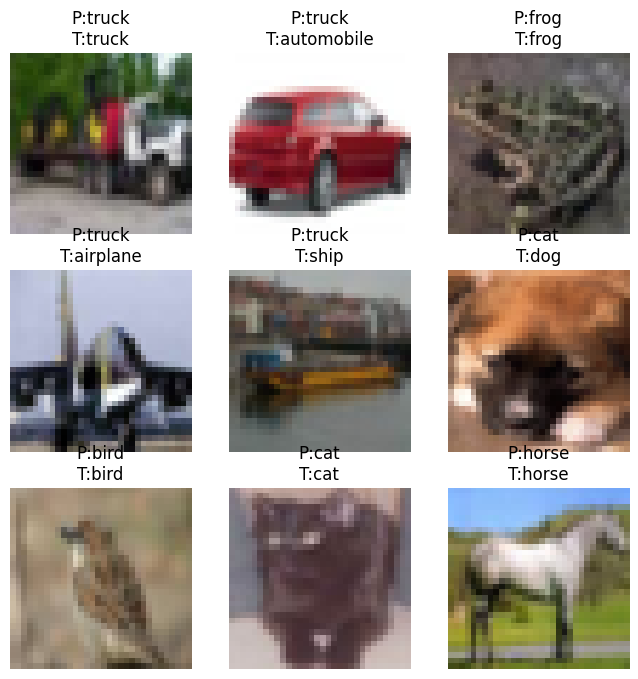

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------
# Dataset
# ---------------------------
transform = transforms.ToTensor()

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=16, shuffle=True)

classes = trainset.classes

# ---------------------------
# Residual Block
# ---------------------------
class Block(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv1 = nn.Conv2d(ch, ch, 3, padding=1)
        self.conv2 = nn.Conv2d(ch, ch, 3, padding=1)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.conv2(self.relu(self.conv1(x))) + x)

# ---------------------------
# Model
# ---------------------------
model = nn.Sequential(
    nn.Conv2d(3, 32, 3, padding=1),
    nn.ReLU(),
    Block(32),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(32*16*16, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
).to(device)

loss_fn = nn.CrossEntropyLoss()
opt = optim.Adam(model.parameters(), lr=0.001)

# ---------------------------
# Training
# ---------------------------
epoch_acc = []

for epoch in range(5):
    correct = total = 0

    for x, y in trainloader:
        x, y = x.to(device), y.to(device)

        out = model(x)
        loss = loss_fn(out, y)

        opt.zero_grad()
        loss.backward()
        opt.step()

        _, pred = torch.max(out, 1)
        total += y.size(0)
        correct += (pred == y).sum().item()

    acc = 100 * correct / total
    epoch_acc.append(acc)

    print(f"Epoch {epoch+1} Accuracy: {acc:.2f}%")

print("Training Done")

# ---------------------------
# Plot Accuracy Graph
# ---------------------------
plt.plot(epoch_acc, marker='o')
plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.show()

# ---------------------------
# Show Predictions
# ---------------------------
dataiter = iter(testloader)
images, labels = next(dataiter)

images, labels = images.to(device), labels.to(device)
outputs = model(images)
_, preds = torch.max(outputs, 1)

images = images.cpu()

plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    img = images[i].permute(1,2,0)
    plt.imshow(img)
    plt.title(f"P:{classes[preds[i]]}\nT:{classes[labels[i]]}")
    plt.axis("off")

plt.show()